# 강화학습 알고리즘 비교 실습: Q-Learning vs DQN vs REINFORCE

**환경:** CartPole-v1 (연속 상태 공간, 이산 행동 공간)  
**목표:** Value-based 방법(Q-Learning, DQN)과 Policy-based 방법(REINFORCE)의 성능 비교

| 알고리즘 | 유형 | 핵심 아이디어 |
|----------|------|---------------|
| Q-Learning | Value-based (Tabular) | 이산화된 상태에서 Q-table 업데이트 |
| DQN | Value-based (Neural) | 신경망으로 Q-function 근사 |
| REINFORCE | Policy-based | 정책을 직접 파라미터화하여 기대 보상 최대화 |

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Q-Learning (Tabular)

CartPole은 연속 상태 공간이므로 이산화(discretization)가 필요합니다.  
이 과정에서 **정보 손실**이 발생하며, bin 수의 선택이 성능에 큰 영향을 줍니다.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

In [2]:
class QLearningAgent:
    def __init__(self, n_bins=12, lr=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.997):
        self.n_bins = n_bins
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.n_actions = 2

        # 상태 공간 이산화 범위 설정
        self.state_bounds = [
            (-2.4, 2.4),     # cart position
            (-3.0, 3.0),     # cart velocity
            (-0.25, 0.25),   # pole angle (rad)
            (-3.5, 3.5),     # pole angular velocity
        ]

        dims = [n_bins] * 4 + [self.n_actions]
        self.q_table = np.zeros(dims)

    def discretize(self, state):
        indices = []
        for i, val in enumerate(state):
            lo, hi = self.state_bounds[i]
            val = np.clip(val, lo, hi)
            idx = int((val - lo) / (hi - lo) * (self.n_bins - 1))
            indices.append(idx)
        return tuple(indices)

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        s = self.discretize(state)
        return int(np.argmax(self.q_table[s]))

    def update(self, state, action, reward, next_state, done):
        s = self.discretize(state)
        s_next = self.discretize(next_state)

        target = reward
        if not done:
            target += self.gamma * np.max(self.q_table[s_next])

        self.q_table[s + (action,)] += self.lr * (target - self.q_table[s + (action,)])

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

## 2. DQN (Deep Q-Network)

신경망으로 Q-function을 근사하며, Experience Replay와 Target Network를 사용합니다.

$$\mathcal{L}(\theta) = \mathbb{E}\left[\left( r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a) \right)^2 \right]$$

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(args)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return zip(*batch)

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, lr=1e-3, gamma=0.99, batch_size=64,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.997,
                 target_update=10, buffer_size=10000):
        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.target_update = target_update
        self.n_actions = 2
        self.update_count = 0

        self.policy_net = QNetwork().to(device)
        self.target_net = QNetwork().to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            return int(self.policy_net(s).argmax(1).item())

    def update(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)

        if len(self.buffer) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        q_values = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            next_q = self.target_net(next_states).max(1, keepdim=True)[0]
            targets = rewards + self.gamma * next_q * (1 - dones)

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

## 3. REINFORCE (Policy Gradient)

정책 $\pi_\theta(a|s)$를 직접 학습합니다. Baseline으로 평균 보상을 사용하여 분산을 줄입니다.

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \left( G_t - b \right) \right]$$

**Policy-based의 장점 (CartPole에서):**
- 연속 상태를 이산화할 필요 없이 직접 처리 (Q-Learning 대비)
- 확률적 정책으로 자연스러운 탐색 → ε-greedy 불필요
- 간결한 정책 네트워크로 빠른 수렴

In [4]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)


class REINFORCEAgent:
    def __init__(self, lr=2e-3, gamma=0.99):
        self.gamma = gamma
        self.policy = PolicyNetwork().to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.log_probs = []
        self.rewards = []

    def select_action(self, state):
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs = self.policy(s)
        dist = Categorical(probs)
        action = dist.sample()
        self.log_probs.append(dist.log_prob(action))
        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def update(self):
        # 할인 누적 보상 계산
        returns = []
        G = 0
        for r in reversed(self.rewards):
            G = r + self.gamma * G
            returns.insert(0, G)

        returns = torch.FloatTensor(returns).to(device)
        # Baseline: 평균 차감 + 정규화
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = 0
        for log_prob, G_t in zip(self.log_probs, returns):
            loss -= log_prob * G_t

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.log_probs = []
        self.rewards = []

## 4. 학습 루프 및 실행

In [5]:
def train_value_based(agent, n_episodes=600, agent_name='Agent'):
    """Q-Learning, DQN 공용 학습 루프"""
    env = gym.make('CartPole-v1')
    scores = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=SEED + ep)
        total_reward = 0

        for _ in range(500):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            if done:
                break

        agent.decay_epsilon()
        scores.append(total_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(scores[-100:])
            print(f'[{agent_name}] Episode {ep+1:4d} | Avg(100): {avg:6.1f} | ε: {agent.epsilon:.3f}')

    env.close()
    return scores


def train_reinforce(agent, n_episodes=600):
    """REINFORCE 학습 루프"""
    env = gym.make('CartPole-v1')
    scores = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=SEED + ep)
        total_reward = 0

        for _ in range(500):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.store_reward(reward)
            state = next_state
            total_reward += reward
            if done:
                break

        agent.update()  # 에피소드 끝에 한 번 업데이트 (Monte Carlo)
        scores.append(total_reward)

        if (ep + 1) % 100 == 0:
            avg = np.mean(scores[-100:])
            print(f'[REINFORCE] Episode {ep+1:4d} | Avg(100): {avg:6.1f}')

    env.close()
    return scores

In [6]:
N_EPISODES = 600

print('=' * 60)
print('1/3  Q-Learning 학습 시작')
print('=' * 60)
ql_agent = QLearningAgent(n_bins=12, lr=0.1, gamma=0.99,
                          epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.997)
ql_scores = train_value_based(ql_agent, N_EPISODES, 'Q-Learn')

print()
print('=' * 60)
print('2/3  DQN 학습 시작')
print('=' * 60)
dqn_agent = DQNAgent(lr=1e-3, gamma=0.99, batch_size=64,
                     epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.997,
                     target_update=10, buffer_size=10000)
dqn_scores = train_value_based(dqn_agent, N_EPISODES, 'DQN')

print()
print('=' * 60)
print('3/3  REINFORCE 학습 시작')
print('=' * 60)
reinforce_agent = REINFORCEAgent(lr=2e-3, gamma=0.99)
reinforce_scores = train_reinforce(reinforce_agent, N_EPISODES)

1/3  Q-Learning 학습 시작
[Q-Learn] Episode  100 | Avg(100):   21.8 | ε: 0.740
[Q-Learn] Episode  200 | Avg(100):   22.7 | ε: 0.548
[Q-Learn] Episode  300 | Avg(100):   28.0 | ε: 0.406
[Q-Learn] Episode  400 | Avg(100):   31.2 | ε: 0.301
[Q-Learn] Episode  500 | Avg(100):   35.0 | ε: 0.223
[Q-Learn] Episode  600 | Avg(100):   38.4 | ε: 0.165

2/3  DQN 학습 시작
[DQN] Episode  100 | Avg(100):   32.2 | ε: 0.740
[DQN] Episode  200 | Avg(100):   63.1 | ε: 0.548
[DQN] Episode  300 | Avg(100):  139.7 | ε: 0.406
[DQN] Episode  400 | Avg(100):  141.3 | ε: 0.301
[DQN] Episode  500 | Avg(100):  257.1 | ε: 0.223
[DQN] Episode  600 | Avg(100):  326.6 | ε: 0.165

3/3  REINFORCE 학습 시작
[REINFORCE] Episode  100 | Avg(100):   36.8
[REINFORCE] Episode  200 | Avg(100):  129.9
[REINFORCE] Episode  300 | Avg(100):  232.9
[REINFORCE] Episode  400 | Avg(100):  117.7
[REINFORCE] Episode  500 | Avg(100):  170.6
[REINFORCE] Episode  600 | Avg(100):  133.0


## 5. 성능 비교 시각화

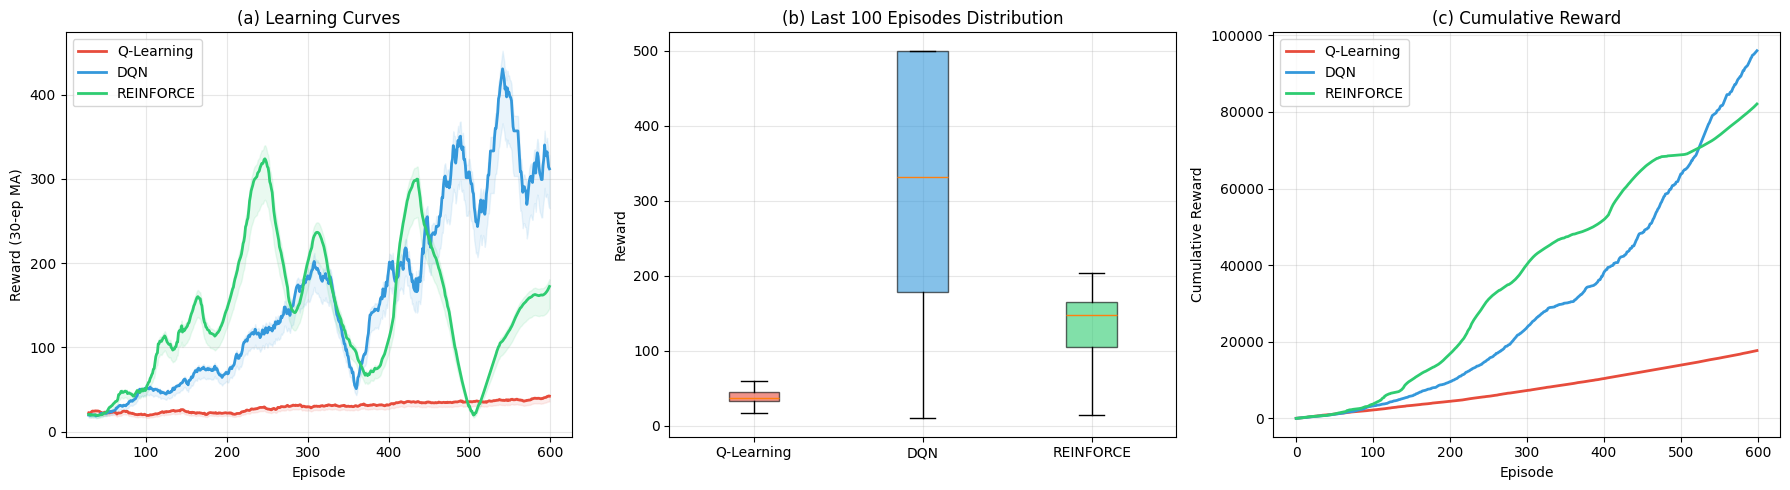

In [7]:
def moving_average(data, window=30):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) 학습 곡선 ---
ax = axes[0]
w = 30
for scores, label, color in [
    (ql_scores, 'Q-Learning', '#e74c3c'),
    (dqn_scores, 'DQN', '#3498db'),
    (reinforce_scores, 'REINFORCE', '#2ecc71'),
]:
    ma = moving_average(scores, w)
    ax.plot(range(w-1, len(scores)), ma, label=label, color=color, linewidth=2)
    ax.fill_between(range(w-1, len(scores)), ma * 0.85, ma * 1.05, alpha=0.1, color=color)

ax.set_xlabel('Episode')
ax.set_ylabel('Reward (30-ep MA)')
ax.set_title('(a) Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# --- (b) 최종 100 에피소드 분포 ---
ax = axes[1]
last100 = [ql_scores[-100:], dqn_scores[-100:], reinforce_scores[-100:]]
labels = ['Q-Learning', 'DQN', 'REINFORCE']
colors = ['#e74c3c', '#3498db', '#2ecc71']
bp = ax.boxplot(last100, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Reward')
ax.set_title('(b) Last 100 Episodes Distribution')
ax.grid(True, alpha=0.3)

# --- (c) 누적 보상 ---
ax = axes[2]
for scores, label, color in [
    (ql_scores, 'Q-Learning', '#e74c3c'),
    (dqn_scores, 'DQN', '#3498db'),
    (reinforce_scores, 'REINFORCE', '#2ecc71'),
]:
    ax.plot(np.cumsum(scores), label=label, color=color, linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title('(c) Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 정량적 비교 테이블
print(f'{"Algorithm":<15} {"Mean(last100)":>14} {"Std":>8} {"Max":>8} {"First>400":>12}')
print('-' * 60)
for name, scores in [('Q-Learning', ql_scores), ('DQN', dqn_scores), ('REINFORCE', reinforce_scores)]:
    last = scores[-100:]
    mean_val = np.mean(last)
    std_val = np.std(last)
    max_val = np.max(scores)
    first400 = next((i for i, s in enumerate(scores) if s >= 400), 'N/A')
    print(f'{name:<15} {mean_val:>14.1f} {std_val:>8.1f} {max_val:>8.0f} {str(first400):>12}')

Algorithm        Mean(last100)      Std      Max    First>400
------------------------------------------------------------
Q-Learning                38.4      8.2       64          N/A
DQN                      326.6    171.6      500          327
REINFORCE                133.0     44.4      500          223


## 6. 분석 및 토론

### REINFORCE가 CartPole에서 우수한 이유

**1. 연속 상태 공간 처리**  
- Q-Learning은 상태를 이산화해야 하므로 정보 손실이 불가피합니다. bin 경계에서 유사한 상태가 완전히 다른 Q값을 가질 수 있습니다.
- REINFORCE는 연속 상태를 신경망에 직접 입력하여 정보 손실 없이 처리합니다.

**2. 탐색 전략**  
- Value-based 방법은 ε-greedy로 탐색하는데, ε 스케줄 튜닝이 성능에 민감합니다.
- REINFORCE의 확률적 정책은 **엔트로피를 자연스럽게 감소**시키며, 초기에 충분히 탐색하고 학습이 진행될수록 자동으로 수렴합니다.

**3. 정책 직접 최적화**  
- DQN은 Q-function을 학습한 뒤 간접적으로 greedy 정책을 도출합니다.
- REINFORCE는 기대 보상을 **직접 최적화**하므로, 목적 함수와 최적화 대상이 일치합니다.

**4. DQN의 오버헤드**  
- DQN은 Replay Buffer가 일정 이상 차야 학습이 시작되고, Target Network 동기화 주기도 조절이 필요합니다.
- CartPole처럼 비교적 단순한 환경에서는 이런 복잡한 메커니즘이 오히려 수렴 속도를 늦출 수 있습니다.

### 한계점 (공정한 비교를 위한 주의사항)
- REINFORCE는 **분산이 높아** 복잡한 환경에서 불안정해질 수 있습니다.
- DQN은 Atari 등 **고차원 환경**에서 REINFORCE보다 우수합니다.
- 하이퍼파라미터 세팅에 따라 결과가 달라질 수 있으므로 **multiple seeds 실험**이 필요합니다.